In [1]:
!pip install -q kaggle tensorflow scikit-learn seaborn pandas matplotlib

In [2]:
import os
import shutil
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import files

uploaded = files.upload()


Saving kaggle.json to kaggle.json


In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [5]:
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset


Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:01<00:00, 148MB/s]



In [6]:
!unzip -q breast-ultrasound-images-dataset.zip -d /content/busi


In [7]:
!find /content/busi -maxdepth 3 -type d


/content/busi
/content/busi/Dataset_BUSI_with_GT
/content/busi/Dataset_BUSI_with_GT/malignant
/content/busi/Dataset_BUSI_with_GT/benign
/content/busi/Dataset_BUSI_with_GT/normal


In [8]:
SOURCE_DIR = "/content/busi/Dataset_BUSI_with_GT"
CLEAN_DIR = "/content/BUSI_clean"

classes = ["benign", "malignant", "normal"]

os.makedirs(CLEAN_DIR, exist_ok=True)

for cls in classes:
    os.makedirs(os.path.join(CLEAN_DIR, cls), exist_ok=True)


In [9]:
for cls in classes:
    source_class_dir = os.path.join(SOURCE_DIR, cls)
    destination_class_dir = os.path.join(CLEAN_DIR, cls)

    for file in os.listdir(source_class_dir):

        # Skip segmentation/ground-truth images
        if "_mask" in file.lower():
            continue

        if file.lower().endswith((".png", ".jpg", ".jpeg")):

            src = os.path.join(source_class_dir, file)
            dst = os.path.join(destination_class_dir, file)

            shutil.copy2(src, dst)

print("Clean dataset created.")


Clean dataset created.


In [10]:
for cls in classes:
    directory = os.path.join(CLEAN_DIR, cls)

    count = len([
        f for f in os.listdir(directory)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    print(f"{cls}: {count}")


benign: 437
malignant: 210
normal: 133


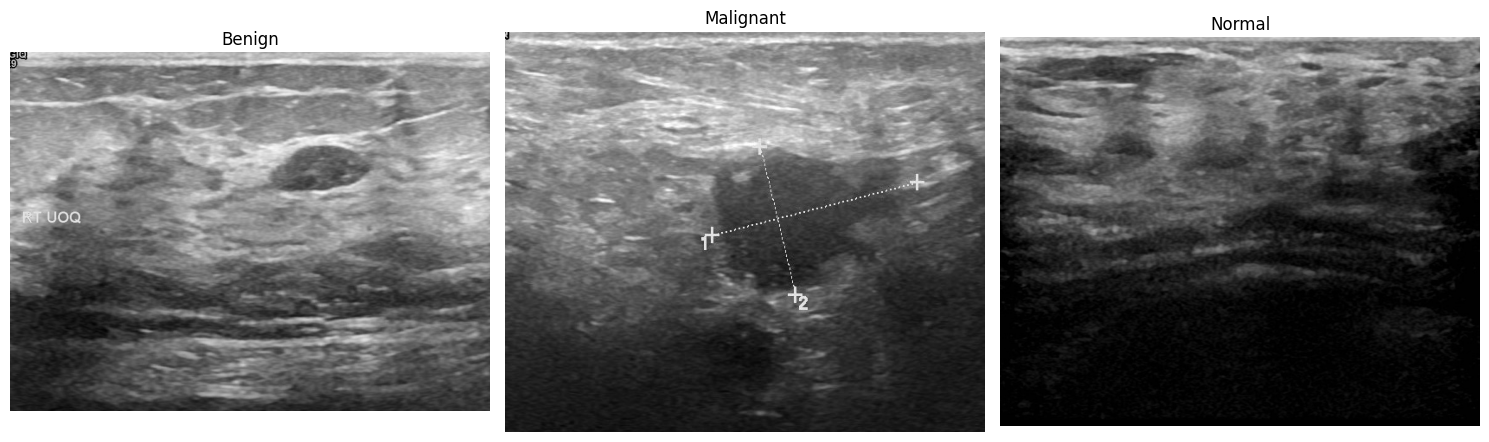

In [11]:
plt.figure(figsize=(15, 5))

for i, cls in enumerate(classes):

    directory = os.path.join(CLEAN_DIR, cls)

    image_files = [
        f for f in os.listdir(directory)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    image_path = os.path.join(directory, image_files[0])

    image = plt.imread(image_path)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(cls.capitalize())
    plt.axis("off")

plt.tight_layout()
plt.show()


In [12]:
data = []

for cls in classes:

    directory = os.path.join(CLEAN_DIR, cls)

    for file in os.listdir(directory):

        if file.lower().endswith((".png", ".jpg", ".jpeg")):

            data.append({
                "filepath": os.path.join(directory, file),
                "label": cls
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
df.head()


Total images: 780


,filepath,label
0,/content/BUSI_clean/benign/benign (390).png,benign
1,/content/BUSI_clean/benign/benign (223).png,benign
2,/content/BUSI_clean/benign/benign (94).png,benign
3,/content/BUSI_clean/benign/benign (129).png,benign
4,/content/BUSI_clean/benign/benign (23).png,benign


In [13]:
print(df["label"].value_counts())


label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


In [14]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)


In [15]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)


In [16]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))


Training: 546
Validation: 117
Testing: 117


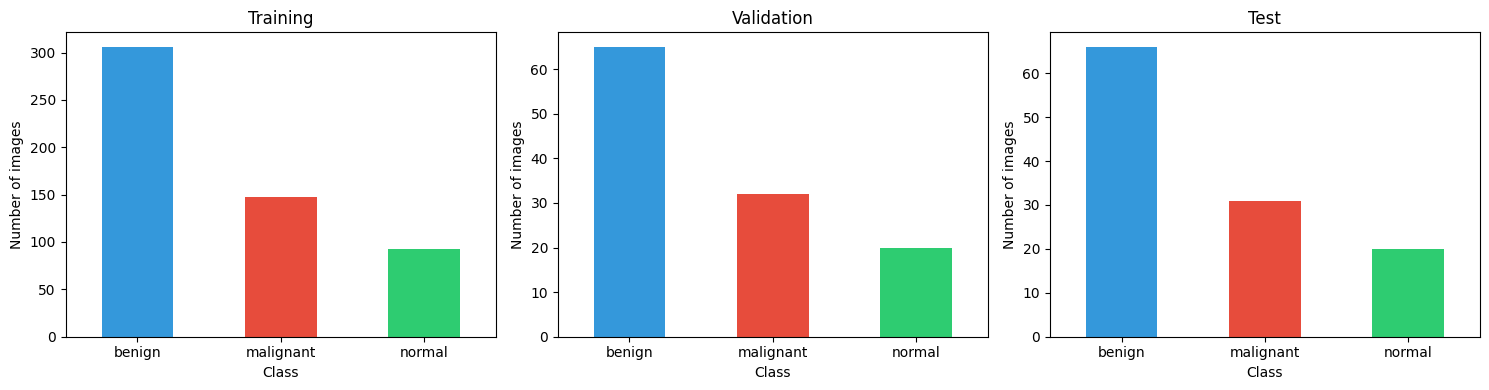

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, dataset, title in zip(
    axes,
    [train_df, val_df, test_df],
    ["Training", "Validation", "Test"]
):

    dataset["label"].value_counts().plot(
        kind="bar",
        ax=ax,
        color=["#3498db", "#e74c3c", "#2ecc71"]
    )

    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of images")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [18]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 3
SEED = 42


In [19]:
class_to_index = {
    "benign": 0,
    "malignant": 1,
    "normal": 2
}

index_to_class = {
    0: "benign",
    1: "malignant",
    2: "normal"
}


In [20]:
def create_dataset(dataframe, shuffle=False):

    paths = dataframe["filepath"].values
    labels = dataframe["label"].map(class_to_index).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    def load_image(path, label):

        image = tf.io.read_file(path)

        image = tf.image.decode_png(
            image,
            channels=3
        )

        image = tf.image.resize(
            image,
            IMG_SIZE
        )

        image = tf.cast(image, tf.float32)

        return image, label

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


In [21]:
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)


In [22]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="data_augmentation")


In [23]:
inputs = keras.Input(
    shape=(224, 224, 3),
    name="input_image"
)

x = data_augmentation(inputs)

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

model = keras.Model(
    inputs,
    outputs
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


In [25]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "/content/best_busi_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]


In [26]:
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/30
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5512 - loss: 0.9796
Epoch 1: val_loss improved from None to 0.79175, saving model to /content/best_busi_model.keras

Epoch 1: finished saving model to /content/best_busi_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 27s 190ms/step - accuracy: 0.5769 - loss: 0.9280 - val_accuracy: 0.6068 - val_loss: 0.7917 - learning_rate: 0.0010
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6339 - loss: 0.8368
Epoch 2: val_loss improved from 0.79175 to 0.72714, saving model to /content/best_busi_model.keras

Epoch 2: finished saving model to /content/best_busi_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.6264 - loss: 0.7943 - val_accuracy: 0.6325 - val_loss: 0.7271 - learning_rate: 0.0010
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6787 - loss: 0.6843
Epoch 3: val_loss improved from 0.72714 to 0.68995, saving model to /content/best_busi_model.keras

Epoch 3: finished saving model to /

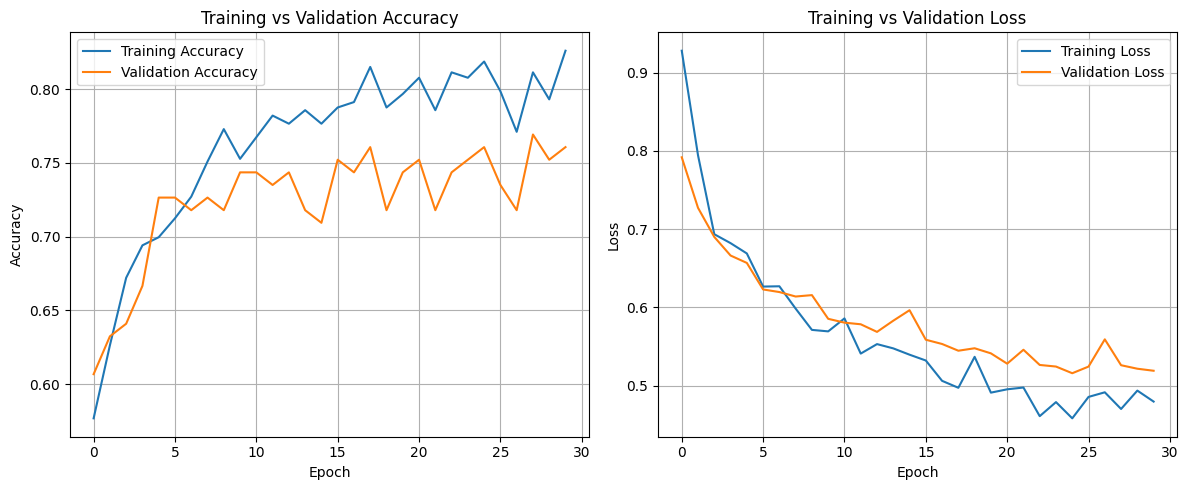

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [28]:
base_model.trainable = True

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False


In [29]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


In [30]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6927 - loss: 0.6987
Epoch 1: val_loss improved from 0.52510 to 0.52021, saving model to /content/best_busi_model.keras

Epoch 1: finished saving model to /content/best_busi_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 25s 175ms/step - accuracy: 0.7033 - loss: 0.6712 - val_accuracy: 0.7778 - val_loss: 0.5202 - learning_rate: 1.0000e-05
Epoch 2/15
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6926 - loss: 0.6594
Epoch 2: val_loss did not improve from 0.52021
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.6978 - loss: 0.6725 - val_accuracy: 0.7863 - val_loss: 0.5233 - learning_rate: 1.0000e-05
Epoch 3/15
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7195 - loss: 0.6310
Epoch 3: val_loss did not improve from 0.52021
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.7271 - loss: 0.6274 - val_accuracy: 0.7778 - val_loss: 0.5261 - learning_rate: 1.0000e-05
Epoch 4/15
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step 

In [28]:
y_prob = model.predict(test_ds)


8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step


In [29]:
y_pred = np.argmax(y_prob, axis=1)


In [30]:
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])


In [31]:
print("True labels shape:", y_true.shape)
print("Predictions shape:", y_pred.shape)


True labels shape: (117,)
Predictions shape: (117,)


In [32]:
efficientnet_accuracy = accuracy_score(
    y_true,
    y_pred
)

print(f"Test Accuracy: {efficientnet_accuracy:.4f}")


Test Accuracy: 0.7607


In [33]:
efficientnet_precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

efficientnet_recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

efficientnet_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Precision: {efficientnet_precision:.4f}")
print(f"Recall:    {efficientnet_recall:.4f}")
print(f"F1-score:  {efficientnet_f1:.4f}")


Precision: 0.7739
Recall:    0.7607
F1-score:  0.7636


In [34]:
class_names = [
    "benign",
    "malignant",
    "normal"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


              precision    recall  f1-score   support

      benign     0.8621    0.7576    0.8065        66
   malignant     0.6286    0.7097    0.6667        31
      normal     0.7083    0.8500    0.7727        20

    accuracy                         0.7607       117
   macro avg     0.7330    0.7724    0.7486       117
weighted avg     0.7739    0.7607    0.7636       117



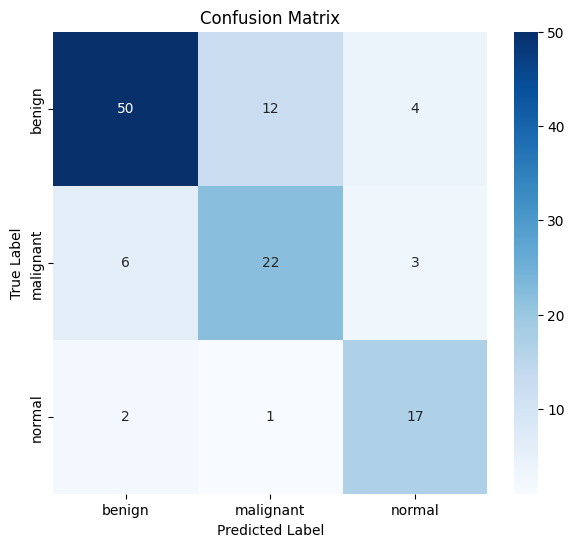

In [35]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()


In [36]:
specificity = {}

for i, class_name in enumerate(class_names):

    TP = cm[i, i]

    FN = cm[i, :].sum() - TP

    FP = cm[:, i].sum() - TP

    TN = cm.sum() - (TP + FN + FP)

    spec = TN / (TN + FP) if (TN + FP) > 0 else 0

    specificity[class_name] = spec

specificity


{'benign': np.float64(0.8431372549019608),
 'malignant': np.float64(0.8488372093023255),
 'normal': np.float64(0.9278350515463918)}

In [37]:
for cls, value in specificity.items():
    print(f"{cls}: specificity = {value:.4f}")


benign: specificity = 0.8431
malignant: specificity = 0.8488
normal: specificity = 0.9278


In [38]:
recall_per_class = recall_score(
    y_true,
    y_pred,
    average=None
)

for cls, value in zip(
    class_names,
    recall_per_class
):
    print(
        f"{cls}: sensitivity/recall = {value:.4f}"
    )


benign: sensitivity/recall = 0.7576
malignant: sensitivity/recall = 0.7097
normal: sensitivity/recall = 0.8500


In [39]:
y_true_onehot = tf.keras.utils.to_categorical(
    y_true,
    num_classes=NUM_CLASSES
)


In [40]:
auc_scores = {}

for i, cls in enumerate(class_names):

    auc_value = roc_auc_score(
        y_true_onehot[:, i],
        y_prob[:, i]
    )

    auc_scores[cls] = auc_value

for cls, value in auc_scores.items():
    print(f"{cls}: ROC-AUC = {value:.4f}")


benign: ROC-AUC = 0.8779
malignant: ROC-AUC = 0.8743
normal: ROC-AUC = 0.9814


In [41]:
macro_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    multi_class="ovr",
    average="macro"
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")


Macro ROC-AUC: 0.9112


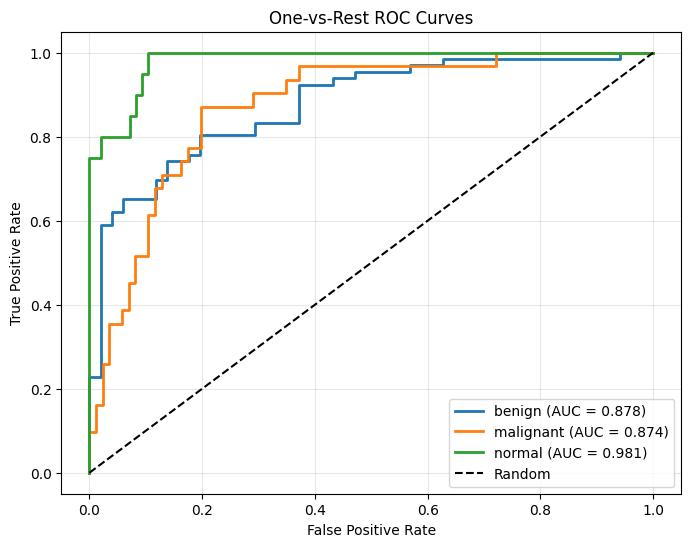

In [42]:
plt.figure(figsize=(8, 6))

for i, cls in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_onehot[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "One-vs-Rest ROC Curves"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()


In [43]:
metrics_table = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Macro ROC-AUC"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        macro_auc
    ]
})

metrics_table


,Metric,Score
0,Accuracy,0.760684
1,Weighted Precision,0.773923
2,Weighted Recall,0.760684
3,Weighted F1,0.763650
4,Macro ROC-AUC,0.911228


In [44]:
metrics_table["Score"] = metrics_table["Score"].round(4)

metrics_table


,Metric,Score
0,Accuracy,0.7607
1,Weighted Precision,0.7739
2,Weighted Recall,0.7607
3,Weighted F1,0.7636
4,Macro ROC-AUC,0.9112


In [45]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

per_class_metrics = pd.DataFrame(report).T

per_class_metrics


,precision,recall,f1-score,support
benign,0.862069,0.757576,0.806452,66.000000
malignant,0.628571,0.709677,0.666667,31.000000
normal,0.708333,0.850000,0.772727,20.000000
accuracy,0.760684,0.760684,0.760684,0.760684
macro avg,0.732991,0.772418,0.748615,117.000000
weighted avg,0.773923,0.760684,0.763650,117.000000


In [46]:
for cls in class_names:

    per_class_metrics.loc[
        cls,
        "specificity"
    ] = specificity[cls]

per_class_metrics.round(4)


,precision,recall,f1-score,support,specificity
benign,0.8621,0.7576,0.8065,66.0000,0.8431
malignant,0.6286,0.7097,0.6667,31.0000,0.8488
normal,0.7083,0.8500,0.7727,20.0000,0.9278
accuracy,0.7607,0.7607,0.7607,0.7607,NaN
macro avg,0.7330,0.7724,0.7486,117.0000,NaN
weighted avg,0.7739,0.7607,0.7636,117.0000,NaN


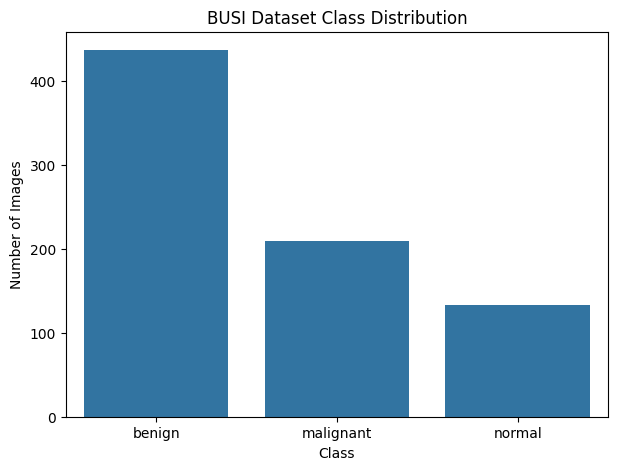

In [47]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label",
    order=class_names
)

plt.title("BUSI Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()


In [48]:
from google.colab import files

uploaded = files.upload()


Saving malignant (101).png to malignant (101).png


In [49]:
image_path = list(uploaded.keys())[0]

img = keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

img_array = keras.utils.img_to_array(img)

img_array = tf.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

predicted_class = class_names[
    np.argmax(prediction)
]

confidence = np.max(prediction)

print("Predicted class:", predicted_class)
print(
    f"Confidence: {confidence * 100:.2f}%"
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted class: malignant
Confidence: 97.17%


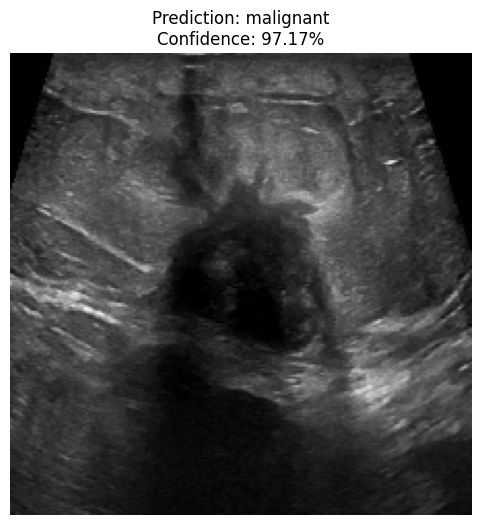

In [50]:
plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()


In [54]:
#model.save(
#    "/content/BUSI_EfficientNetB0.keras"
#)

#print("Model saved successfully.")


In [55]:
#from google.colab import files

#files.download(
#    "/content/BUSI_EfficientNetB0.keras"
#)


In [57]:
#metrics_table.to_csv(
#    "/content/BUSI_metrics.csv",
#    index=False
#)

#per_class_metrics.to_csv(
#    "/content/BUSI_per_class_metrics.csv"
#)


In [58]:
#files.download(
#    "/content/BUSI_metrics.csv"
#)


In [51]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)


In [52]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")


In [53]:
classes = np.array([0, 1, 2])

y_train = train_df["label"].map({
    "benign": 0,
    "malignant": 1,
    "normal": 2
}).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    i: weights[i]
    for i in range(len(weights))
}

print("Class weights:")
print(class_weights)


Class weights:
{0: np.float64(0.5947712418300654), 1: np.float64(1.2380952380952381), 2: np.float64(1.956989247311828)}


In [54]:
IMG_SIZE = (224, 224)

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze pretrained network initially
base_model.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [55]:
inputs = keras.Input(
    shape=(224, 224, 3),
    name="input"
)

x = data_augmentation(inputs)

# ResNet50 preprocessing
x = tf.keras.applications.resnet50.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.5)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

resnet50_model = keras.Model(
    inputs,
    outputs
)

resnet50_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        771 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,121,219 (92.02 MB)

 Trainable params: 529,411 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [56]:
resnet50_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)


In [57]:
callbacks = [

    keras.callbacks.ModelCheckpoint(
        "/content/best_resnet50.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]


In [58]:
history_resnet = resnet50_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5490 - loss: 1.6695
Epoch 1: val_loss improved from None to 0.84949, saving model to /content/best_resnet50.keras

Epoch 1: finished saving model to /content/best_resnet50.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 25s 267ms/step - accuracy: 0.5952 - loss: 1.4393 - val_accuracy: 0.6923 - val_loss: 0.8495 - learning_rate: 0.0010
Epoch 2/15
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6733 - loss: 1.0454
Epoch 2: val_loss improved from 0.84949 to 0.74923, saving model to /content/best_resnet50.keras

Epoch 2: finished saving model to /content/best_resnet50.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.6905 - loss: 0.9520 - val_accuracy: 0.7009 - val_loss: 0.7492 - learning_rate: 0.0010
Epoch 3/15
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7469 - loss: 0.8733
Epoch 3: val_loss improved from 0.74923 to 0.62540, saving model to /content/best_resnet50.keras

Epoch 3: finished saving model to /content/be

In [59]:
base_model.trainable = True


In [60]:
for layer in base_model.layers[:-30]:
    layer.trainable = False


In [61]:
for layer in base_model.layers:

    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False


In [62]:
trainable_layers = sum(
    layer.trainable
    for layer in resnet50_model.layers
)

print(
    "Trainable layers:",
    trainable_layers
)


Trainable layers: 9


In [63]:
resnet50_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


In [64]:
fine_history_resnet = resnet50_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7663 - loss: 0.7418
Epoch 1: val_loss improved from 0.57546 to 0.53318, saving model to /content/best_resnet50.keras

Epoch 1: finished saving model to /content/best_resnet50.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 24s 249ms/step - accuracy: 0.7509 - loss: 0.7850 - val_accuracy: 0.7863 - val_loss: 0.5332 - learning_rate: 1.0000e-05
Epoch 2/20
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.7932 - loss: 0.5709
Epoch 2: val_loss did not improve from 0.53318
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.7839 - loss: 0.6087 - val_accuracy: 0.7692 - val_loss: 0.5681 - learning_rate: 1.0000e-05
Epoch 3/20
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7772 - loss: 0.5541
Epoch 3: val_loss improved from 0.53318 to 0.52849, saving model to /content/best_resnet50.keras

Epoch 3: finished saving model to /content/best_resnet50.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.7802 - loss: 0.6064 - val_a

In [65]:
y_prob_resnet = resnet50_model.predict(
    test_ds
)


7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 603ms/step


In [66]:
y_pred_resnet = np.argmax(
    y_prob_resnet,
    axis=1
)


In [67]:
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])


In [68]:
resnet_accuracy = accuracy_score(
    y_true,
    y_pred_resnet
)

print(
    f"ResNet50 Accuracy: "
    f"{resnet_accuracy:.4f}"
)


ResNet50 Accuracy: 0.7521


In [69]:
resnet_precision = precision_score(
    y_true,
    y_pred_resnet,
    average="weighted"
)

resnet_recall = recall_score(
    y_true,
    y_pred_resnet,
    average="weighted"
)

resnet_f1 = f1_score(
    y_true,
    y_pred_resnet,
    average="weighted"
)

print(
    f"Precision: {resnet_precision:.4f}"
)

print(
    f"Recall:    {resnet_recall:.4f}"
)

print(
    f"F1-score:  {resnet_f1:.4f}"
)


Precision: 0.7763
Recall:    0.7521
F1-score:  0.7562


In [70]:
print(
    classification_report(
        y_true,
        y_pred_resnet,
        target_names=class_names,
        digits=4
    )
)


              precision    recall  f1-score   support

      benign     0.8704    0.7121    0.7833        66
   malignant     0.6000    0.7742    0.6761        31
      normal     0.7391    0.8500    0.7907        20

    accuracy                         0.7521       117
   macro avg     0.7365    0.7788    0.7500       117
weighted avg     0.7763    0.7521    0.7562       117



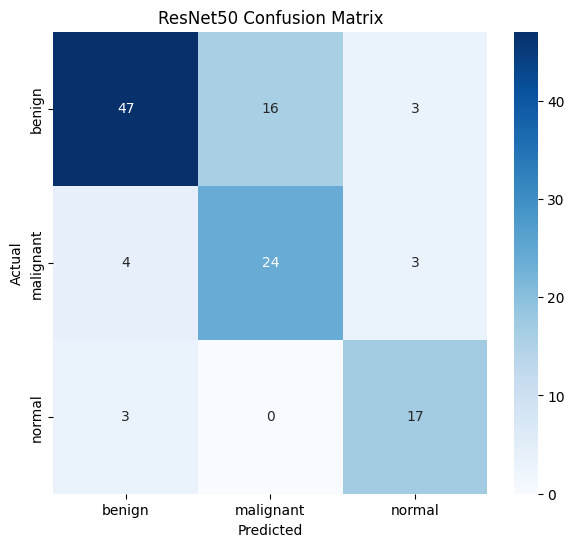

In [71]:
cm_resnet = confusion_matrix(
    y_true,
    y_pred_resnet
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "ResNet50 Confusion Matrix"
)

plt.show()


In [72]:
specificity_resnet = {}

for i, class_name in enumerate(class_names):

    TP = cm_resnet[i, i]

    FN = cm_resnet[i, :].sum() - TP

    FP = cm_resnet[:, i].sum() - TP

    TN = cm_resnet.sum() - (
        TP + FN + FP
    )

    specificity_resnet[class_name] = (
        TN / (TN + FP)
        if (TN + FP) > 0
        else 0
    )

for cls, value in specificity_resnet.items():

    print(
        f"{cls}: "
        f"{value:.4f}"
    )


benign: 0.8627
malignant: 0.8140
normal: 0.9381


In [73]:
y_true_onehot = tf.keras.utils.to_categorical(
    y_true,
    num_classes=3
)

resnet_auc = roc_auc_score(
    y_true_onehot,
    y_prob_resnet,
    multi_class="ovr",
    average="macro"
)

print(
    f"ResNet50 Macro ROC-AUC: "
    f"{resnet_auc:.4f}"
)


ResNet50 Macro ROC-AUC: 0.9211


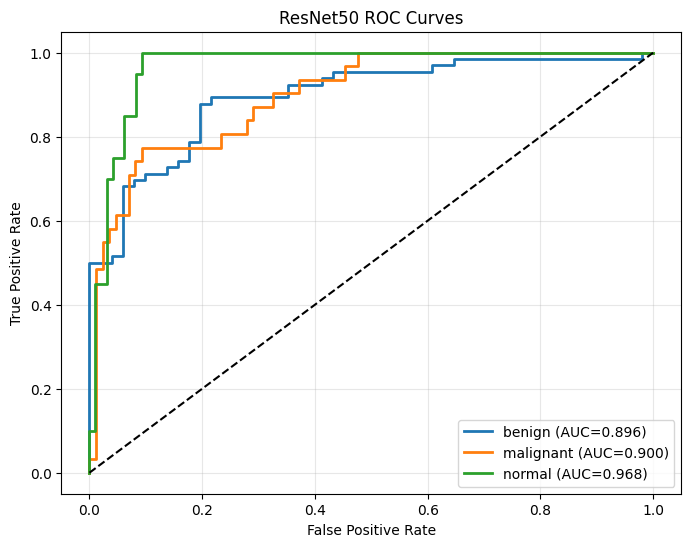

In [74]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_onehot[:, i],
        y_prob_resnet[:, i]
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC={roc_auc_value:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ResNet50 ROC Curves"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()
